In [22]:
from dataclasses import dataclass
from typing import Optional

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.axes import Axes


@dataclass
class Instrument:
    """Instrument data container."""
    ID: str
    energy_res: float   # [eV]
    fov: float          # [sr]
    psla: float         # [arcmin]


def make_fig_layout(
    ax: Axes,
    xlims: Optional[tuple],
    ylims: Optional[tuple],
    xlabel: str,
    ylabel: str
) -> tuple[Figure, Axes]:
    ax.set_xscale('linear'); ax.set_yscale('log')
    ax.set_xlim(*xlims); ax.set_ylim(*ylims)
    ax.set_xlabel(xlabel=xlabel); ax.set_ylabel(ylabel=ylabel)
    ax.xaxis.set_ticks_position('both'); ax.yaxis.set_ticks_position('both')
    ax.tick_params(which='both', direction='in', width=1.5, length=4 if 'major' else 2.5)
    ax.grid(True, linewidth=0.1, alpha=0.85)
    return


def plot_FoV_vs_PSLA(
    instruments: list[Instrument],
    save_to: Optional[str] = None,
    save_kws: Optional[dict] = None,
    **fig_kws,
) -> None:
    fig, ax = plt.subplots(1, 1, tight_layout=True, **fig_kws)
    ax.set_title('High-Energy Transient Monitors: FoV vs Localisation Accuracy')

    for instr in instruments:
        loc = (instr.fov, instr.psla)
        ax.scatter(*loc)
        ax.text(*loc, instr.ID)

    make_fig_layout(ax, (None, None), (None, None), 'FoV (solid angle) [sr]', 'Localisation Accuracy [arcmin]')

    if save_to is not None:
        save_kws = save_kws or {}
        fig.savefig(save_to, **save_kws)
    plt.show()

    return


def plot_FoV_vs_EnergyRes(
    instruments: list[Instrument],
    save_to: Optional[str] = None,
    save_kws: Optional[dict] = None,
    **fig_kws,
) -> None:
    fig, ax = plt.subplots(1, 1, tight_layout=True, **fig_kws)
    ax.set_title('High-Energy Transient Monitors: FoV vs Energy Resolution')

    for instr in instruments:
        loc = np.array([instr.fov, instr.energy_res])
        offset = np.array([0.2, instr.energy_res / 5])
        ax.scatter(*loc)
        ax.text(*(loc + offset), instr.ID)

    make_fig_layout(ax, (None, None), (None, None), 'FoV (solid angle) [sr]', 'Energy Resolution [eV]')

    if save_to is not None:
        save_kws = save_kws or {}
        fig.savefig(save_to, **save_kws)
    plt.show()

    return

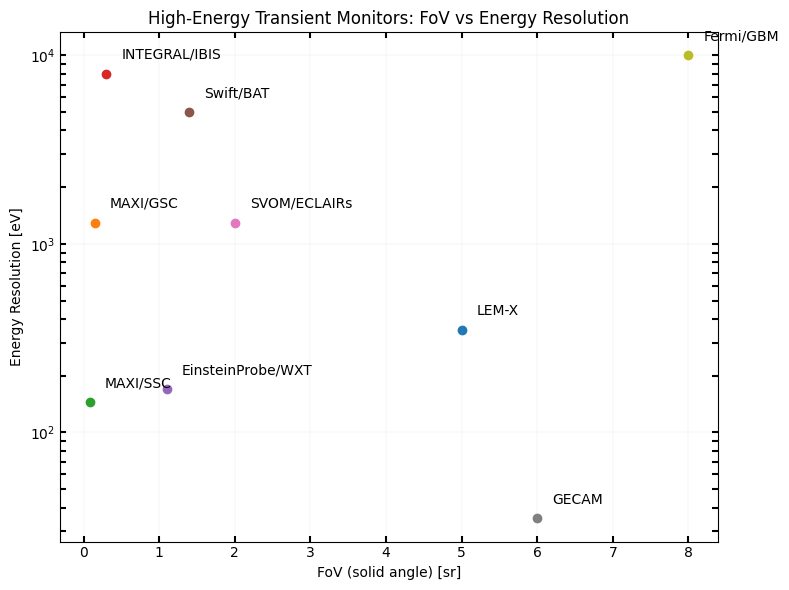

In [24]:
instrs = [
    Instrument('LEM-X', energy_res=350, fov=5, psla=1),

    Instrument('MAXI/GSC', energy_res=1300, fov=0.15, psla=12),
    Instrument('MAXI/SSC', energy_res=145, fov=0.08, psla=6),
    Instrument('INTEGRAL/IBIS', energy_res=8000, fov=0.3, psla=3),
    Instrument('EinsteinProbe/WXT', energy_res=170, fov=1.1, psla=5),
    Instrument('Swift/BAT', energy_res=5000, fov=1.4, psla=4),
    Instrument('SVOM/ECLAIRs', energy_res=1300, fov=2, psla=12),
    Instrument('GECAM', energy_res=35, fov=6, psla=120),
    Instrument('Fermi/GBM', energy_res=10000, fov=8, psla=900),
]

# plot_FoV_vs_PSLA(instrs, figsize=(6, 4.5))
plot_FoV_vs_EnergyRes(instrs, figsize=(8, 6))